# Weather Dataset Validation
Comprehensive validation of the processed weather dataset

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [37]:
DATA_PATH = Path("../../data/processed/weather.parquet")

df = pd.read_parquet(DATA_PATH)

print(f"Weather dataset shape: {df.shape}")
print(f"\nLocations: {df['location_name'].unique()}")

Weather dataset shape: (4052, 25)

Locations: <ArrowStringArray>
['seoul', 'pohang']
Length: 2, dtype: str


In [38]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 4052 entries, 0 to 4051
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   location_name                     4052 non-null   str           
 1   date                              4052 non-null   datetime64[us]
 2   avg_temperature(°C)               4052 non-null   float64       
 3   min_temperature(°C)               4052 non-null   float64       
 4   max_temperature(°C)               4052 non-null   float64       
 5   precipitation_duration(hr)        4052 non-null   float64       
 6   daily_precipitation(mm)           4052 non-null   float64       
 7   max_gust_wind_speed(m/s)          4052 non-null   float64       
 8   max_wind_speed(m/s)               4052 non-null   float64       
 9   avg_wind_speed(m/s)               4052 non-null   float64       
 10  avg_dew_point(°C)                 4052

In [39]:
df.head()

,location_name,date,avg_temperature(°C),min_temperature(°C),max_temperature(°C),precipitation_duration(hr),daily_precipitation(mm),max_gust_wind_speed(m/s),max_wind_speed(m/s),avg_wind_speed(m/s),...,min_sea_level_pressure(hPa),avg_sea_level_pressure(hPa),sunshine_possible_hours,total_sunshine_hours,total_solar_radiation(MJ/m2),daily_max_new_snow_depth(cm),avg_cloud_cover(1/10),fog_occured,most_frequent_wind_direction_sin,most_frequent_wind_direction_cos
0,seoul,2020-11-01,13.7,11.6,15.0,7.17,13.6,10.8,4.5,2.3,...,1017.7,1019.5,10.6,0.0,1.61,0.0,8.6,False,-0.342020,-9.396926e-01
1,pohang,2020-11-01,13.9,12.6,14.7,7.75,0.4,6.3,3.9,2.3,...,1018.9,1020.8,10.7,0.0,2.38,0.0,9.8,False,-0.766044,-6.427876e-01
2,seoul,2020-11-02,10.8,7.9,15.6,2.33,1.7,8.7,4.9,2.3,...,1019.1,1020.4,10.6,9.6,14.60,0.0,3.0,False,-1.000000,-1.836970e-16
3,pohang,2020-11-02,14.2,10.0,18.2,0.00,0.0,5.2,3.5,2.1,...,1018.0,1019.4,10.7,3.9,9.07,0.0,6.5,False,-0.939693,-3.420201e-01
4,seoul,2020-11-03,5.1,2.7,8.6,0.83,0.5,15.6,8.4,3.5,...,1019.6,1022.5,10.6,9.2,15.22,0.0,1.5,False,-1.000000,-1.836970e-16


In [40]:
df.tail()

,location_name,date,avg_temperature(°C),min_temperature(°C),max_temperature(°C),precipitation_duration(hr),daily_precipitation(mm),max_gust_wind_speed(m/s),max_wind_speed(m/s),avg_wind_speed(m/s),...,min_sea_level_pressure(hPa),avg_sea_level_pressure(hPa),sunshine_possible_hours,total_sunshine_hours,total_solar_radiation(MJ/m2),daily_max_new_snow_depth(cm),avg_cloud_cover(1/10),fog_occured,most_frequent_wind_direction_sin,most_frequent_wind_direction_cos
4047,seoul,2026-05-17,22.6,16.2,29.4,0.00,0.00,7.2,3.7,1.9,...,1016.5,1019.3,14.2,12.9,29.69,0.0,1.9,False,-1.000000,-1.836970e-16
4048,pohang,2026-05-18,26.7,18.6,33.7,0.00,0.00,7.8,4.2,2.4,...,1011.4,1014.5,14.1,12.8,29.50,0.0,0.6,False,-0.766044,-6.427876e-01
4049,seoul,2026-05-18,23.0,15.7,30.1,0.00,0.00,8.4,4.3,2.1,...,1014.0,1016.0,14.3,11.9,28.31,0.0,5.3,False,-1.000000,-1.836970e-16
4050,seoul,2026-05-19,22.1,19.8,25.5,0.25,0.01,10.0,4.4,1.9,...,1010.6,1013.8,14.3,0.4,10.02,0.0,9.9,False,0.766044,6.427876e-01
4051,pohang,2026-05-19,23.6,19.2,30.0,0.00,0.00,7.9,5.1,2.6,...,1010.8,1013.4,14.2,10.0,24.69,0.0,6.5,False,-0.939693,-3.420201e-01


In [41]:
print("=== Date Range ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location]
    print(f"{location.upper()}:")
    print(f"  Min date: {df_loc['date'].min()}")
    print(f"  Max date: {df_loc['date'].max()}")
    print(f"  Days: {len(df_loc)}")
    print()

=== Date Range ===
SEOUL:
  Min date: 2020-11-01 00:00:00
  Max date: 2026-05-19 00:00:00
  Days: 2026

POHANG:
  Min date: 2020-11-01 00:00:00
  Max date: 2026-05-19 00:00:00
  Days: 2026



In [42]:
print("=== Duplicate Dates ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location]
    duplicates = df_loc['date'].duplicated().sum()
    print(f"{location}: {duplicates}")
    print()

=== Duplicate Dates ===
seoul: 0

pohang: 0



In [43]:
print("=== Missing Dates ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location].sort_values('date')
    expected_dates = pd.date_range(
        start=df_loc['date'].min(),
        end=df_loc['date'].max(),
        freq="D"
    )
    
    missing_dates = expected_dates.difference(df_loc['date'])
    
    print(f"{location}:")
    print(f"  Missing dates: {len(missing_dates)}")
    if len(missing_dates) > 0:
        print(f"  First few: {missing_dates[:5].tolist()}")
    print()

=== Missing Dates ===
seoul:
  Missing dates: 0

pohang:
  Missing dates: 0



In [44]:
print("=== Missing Values ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location]
    print(f"{location}:")
    missing = df_loc.isna().sum().sort_values(ascending=False)
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("  No missing values")
    print()

=== Missing Values ===
seoul:
  No missing values

pohang:
  No missing values



In [45]:
print("=== Numeric Columns Statistics ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location]
    print(f"{location.upper()}:")
    numeric_cols = df_loc.select_dtypes(include=np.number).columns
    print(df_loc[numeric_cols].describe().T)
    print()

=== Numeric Columns Statistics ===
SEOUL:
                                   count         mean        std    min  \
avg_temperature(°C)               2026.0    13.267621  10.743236  -14.9   
min_temperature(°C)               2026.0     9.202588  11.022096  -18.6   
max_temperature(°C)               2026.0    18.002863  10.734885  -10.7   
precipitation_duration(hr)        2026.0     2.514403   4.843278    0.0   
daily_precipitation(mm)           2026.0     3.803421  13.349655    0.0   
max_gust_wind_speed(m/s)          2026.0     8.441265   2.637747    3.5   
max_wind_speed(m/s)               2026.0     4.731176   1.250157    2.4   
avg_wind_speed(m/s)               2026.0     2.320215   0.647413    1.1   
avg_dew_point(°C)                 2026.0     6.164265  11.900572  -24.5   
min_relative_humidity(%)          2026.0    44.565153  16.396780   10.0   
avg_humidity(%)                   2026.0    64.708983  14.030498   22.9   
avg_local_pressure(hPa)           2026.0  1006.146989   7.

                                   count         mean        std     min  \
avg_temperature(°C)               2026.0    14.940424   9.171447   -9.10   
min_temperature(°C)               2026.0    11.199062   9.577301  -13.90   
max_temperature(°C)               2026.0    19.149901   9.031517   -4.50   
precipitation_duration(hr)        2026.0     2.136802   4.405940    0.00   
daily_precipitation(mm)           2026.0     2.909269  12.287289    0.00   
max_gust_wind_speed(m/s)          2026.0     8.626999   2.562660    3.40   
max_wind_speed(m/s)               2026.0     5.511402   1.421362    2.30   
avg_wind_speed(m/s)               2026.0     2.750790   0.825460    1.00   
avg_dew_point(°C)                 2026.0     6.488401  12.113917  -25.00   
min_relative_humidity(%)          2026.0    42.839832  20.392614    0.00   
avg_humidity(%)                   2026.0    60.473692  18.134225   14.40   
avg_local_pressure(hPa)           2026.0  1015.830109   7.573713  993.10   
max_sea_leve

In [46]:
print("=== Negative Values Check ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location]
    print(f"{location}:")
    numeric_cols = df_loc.select_dtypes(include=np.number).columns
    negative_exists = False
    for col in numeric_cols:
        n_neg = (df_loc[col] < 0).sum()
        if n_neg > 0:
            print(f"  {col}: {n_neg} negative values")
            negative_exists = True
    if not negative_exists:
        print("  No negative values found.")
    print()

=== Negative Values Check ===
seoul:
  avg_temperature(°C): 267 negative values
  min_temperature(°C): 488 negative values
  max_temperature(°C): 104 negative values
  avg_dew_point(°C): 678 negative values
  most_frequent_wind_direction_sin: 1135 negative values
  most_frequent_wind_direction_cos: 1001 negative values

pohang:
  avg_temperature(°C): 97 negative values
  min_temperature(°C): 276 negative values
  max_temperature(°C): 18 negative values
  avg_dew_point(°C): 616 negative values
  most_frequent_wind_direction_sin: 1446 negative values
  most_frequent_wind_direction_cos: 1366 negative values



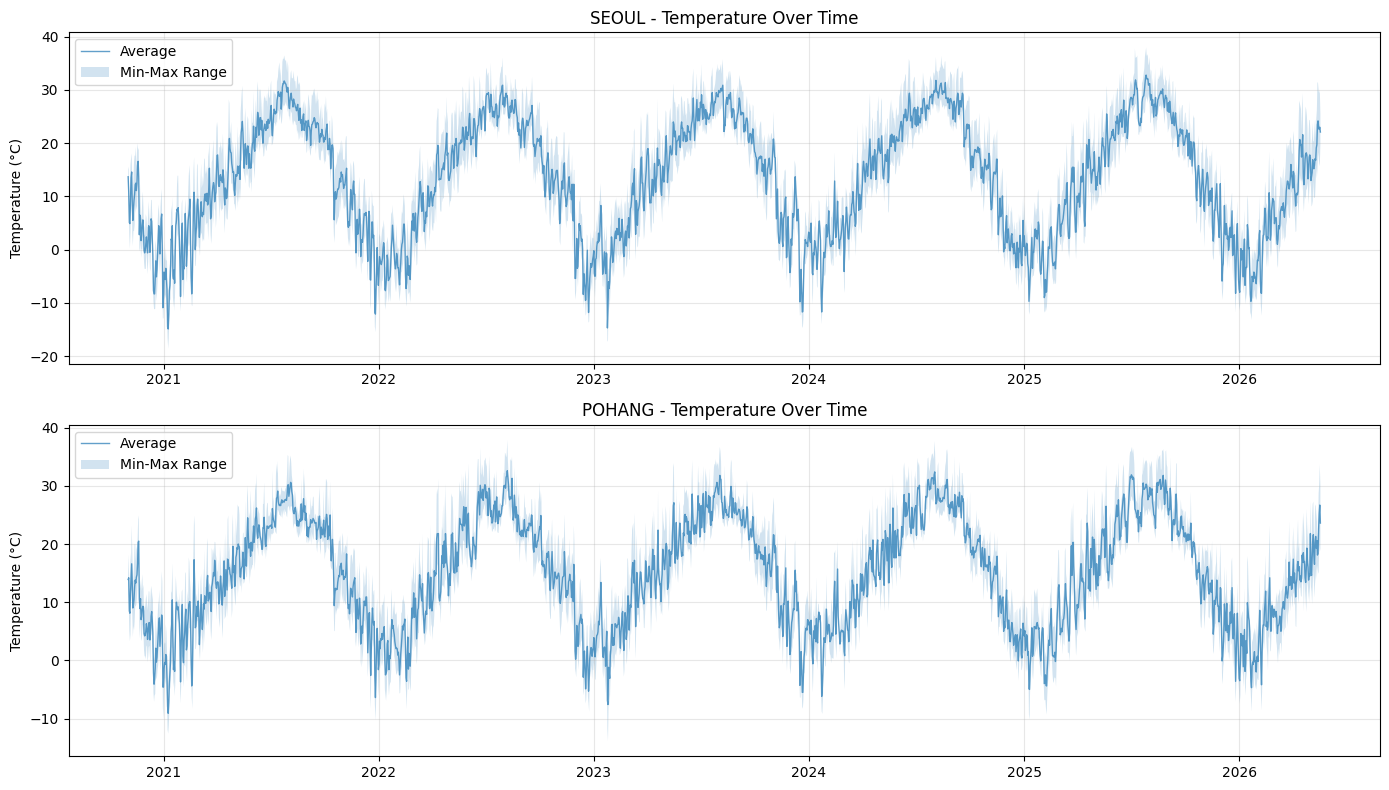

In [47]:
# Temperature trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, location in enumerate(df['location_name'].unique()):
    df_loc = df[df['location_name'] == location].sort_values('date')
    
    axes[idx].plot(df_loc['date'], df_loc['avg_temperature(°C)'], label='Average', linewidth=1, alpha=0.7)
    axes[idx].fill_between(df_loc['date'], df_loc['min_temperature(°C)'], df_loc['max_temperature(°C)'], 
                            alpha=0.2, label='Min-Max Range')
    axes[idx].set_title(f"{location.upper()} - Temperature Over Time")
    axes[idx].set_ylabel("Temperature (°C)")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

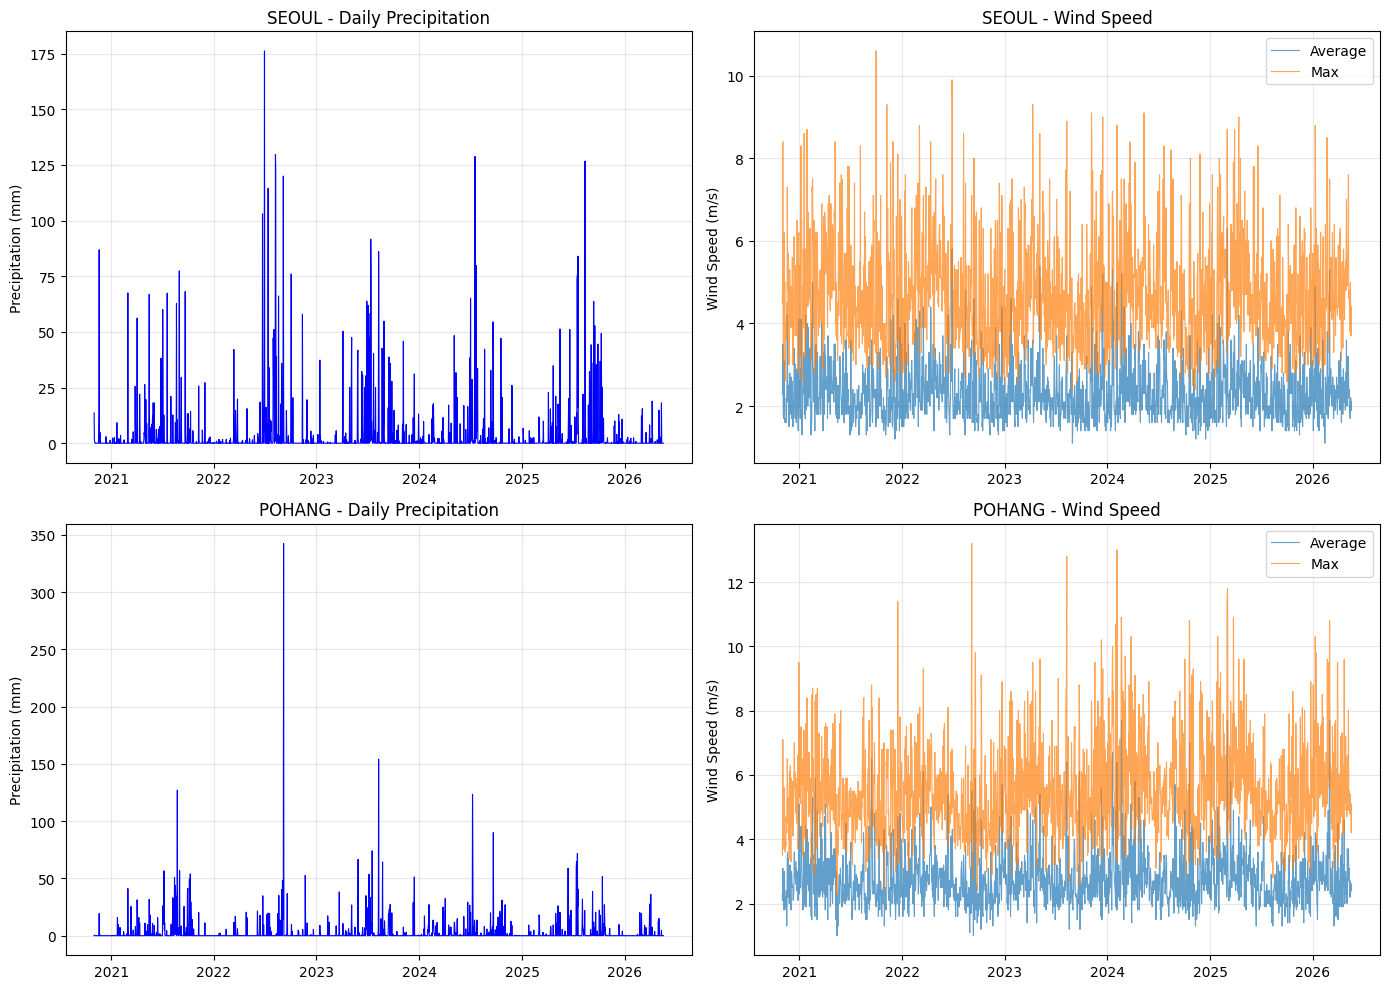

In [48]:
# Precipitation and wind
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

locations = df['location_name'].unique()

for idx, location in enumerate(locations):
    df_loc = df[df['location_name'] == location].sort_values('date')
    
    # Precipitation
    axes[idx, 0].plot(df_loc['date'], df_loc['daily_precipitation(mm)'], linewidth=0.8, color='blue')
    axes[idx, 0].set_title(f"{location.upper()} - Daily Precipitation")
    axes[idx, 0].set_ylabel("Precipitation (mm)")
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Wind speed
    axes[idx, 1].plot(df_loc['date'], df_loc['avg_wind_speed(m/s)'], label='Average', linewidth=0.8, alpha=0.7)
    axes[idx, 1].plot(df_loc['date'], df_loc['max_wind_speed(m/s)'], label='Max', linewidth=0.8, alpha=0.7)
    axes[idx, 1].set_title(f"{location.upper()} - Wind Speed")
    axes[idx, 1].set_ylabel("Wind Speed (m/s)")
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

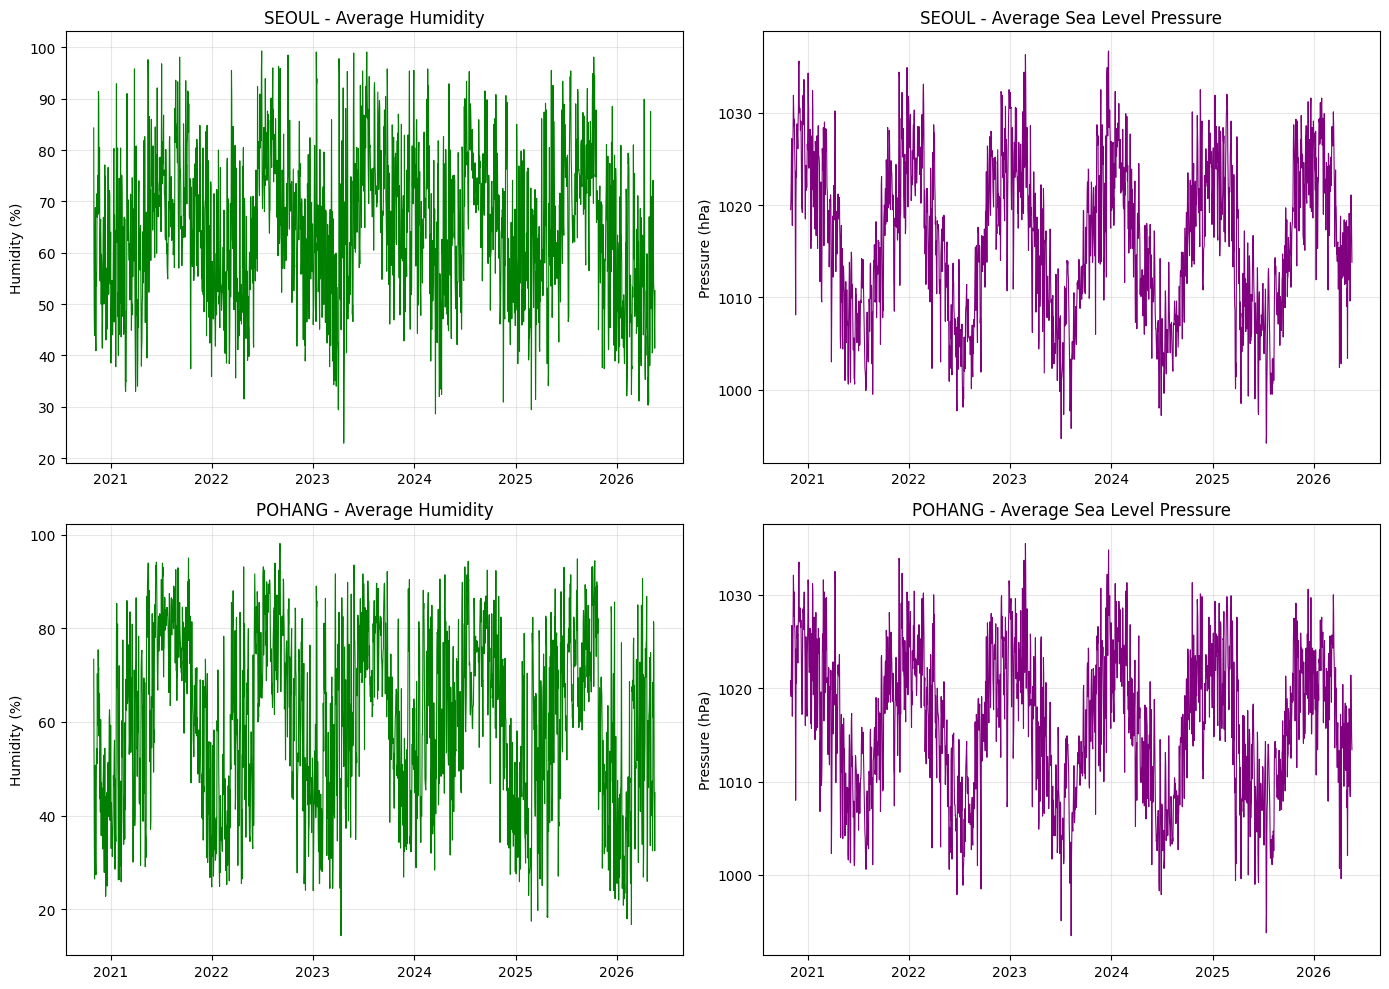

In [49]:
# Humidity and pressure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

locations = df['location_name'].unique()

for idx, location in enumerate(locations):
    df_loc = df[df['location_name'] == location].sort_values('date')
    
    # Humidity
    axes[idx, 0].plot(df_loc['date'], df_loc['avg_humidity(%)'], linewidth=0.8, color='green')
    axes[idx, 0].set_title(f"{location.upper()} - Average Humidity")
    axes[idx, 0].set_ylabel("Humidity (%)")
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Sea level pressure
    axes[idx, 1].plot(df_loc['date'], df_loc['avg_sea_level_pressure(hPa)'], linewidth=0.8, color='purple')
    axes[idx, 1].set_title(f"{location.upper()} - Average Sea Level Pressure")
    axes[idx, 1].set_ylabel("Pressure (hPa)")
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
print("=== Top 10 Wettest Days ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location]
    print(f"{location}:")
    print(df_loc.nlargest(10, 'daily_precipitation(mm)')[['date', 'daily_precipitation(mm)']])
    print()

=== Top 10 Wettest Days ===
seoul:
           date  daily_precipitation(mm)
1213 2022-06-30                    176.2
1291 2022-08-08                    129.6
2710 2024-07-18                    128.8
3493 2025-08-13                    126.7
1293 2022-08-09                    123.1
1346 2022-09-05                    120.0
1239 2022-07-13                    114.5
1199 2022-06-23                    103.0
2708 2024-07-17                     98.8
1968 2023-07-13                     91.6

pohang:
           date  daily_precipitation(mm)
1349 2022-09-06                    342.4
2024 2023-08-10                    154.2
592  2021-08-24                    127.1
2692 2024-07-09                    123.4
2840 2024-09-21                     89.9
2694 2024-07-10                     74.8
1979 2023-07-18                     74.1
3439 2025-07-17                     71.6
1879 2023-05-29                     66.6
3433 2025-07-14                     64.8



In [51]:
print("=== Top 10 Hottest Days ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location]
    print(f"{location}:")
    print(df_loc.nlargest(10, 'max_temperature(°C)')[['date', 'max_temperature(°C)']])
    print()

=== Top 10 Hottest Days ===
seoul:
           date  max_temperature(°C)
3459 2025-07-27                 38.0
3421 2025-07-08                 37.8
3456 2025-07-26                 37.1
3463 2025-07-29                 36.7
531  2021-07-24                 36.5
3428 2025-07-12                 36.5
2762 2024-08-13                 36.4
3460 2025-07-28                 36.4
3455 2025-07-25                 36.3
3465 2025-07-30                 36.3

pohang:
           date  max_temperature(°C)
1288 2022-08-07                 37.9
2741 2024-08-02                 37.7
2011 2023-08-03                 36.7
3411 2025-07-03                 36.7
1196 2022-06-22                 36.5
3415 2025-07-05                 36.4
2782 2024-08-23                 36.3
3409 2025-07-02                 36.3
3517 2025-08-25                 36.3
2739 2024-08-01                 36.2



In [52]:
print("=== Top 10 Coldest Days ===")
for location in df['location_name'].unique():
    df_loc = df[df['location_name'] == location]
    print(f"{location}:")
    print(df_loc.nsmallest(10, 'min_temperature(°C)')[['date', 'min_temperature(°C)']])
    print()

=== Top 10 Coldest Days ===
seoul:
           date  min_temperature(°C)
136  2021-01-08                -18.6
1630 2023-01-25                -17.3
1628 2023-01-24                -17.0
138  2021-01-09                -16.6
135  2021-01-07                -16.5
840  2021-12-26                -15.5
2292 2023-12-22                -14.7
838  2021-12-25                -14.4
2290 2023-12-21                -14.4
2357 2024-01-23                -14.0

pohang:
           date  min_temperature(°C)
1631 2023-01-25                -13.9
137  2021-01-08                -12.6
134  2021-01-07                -11.9
1629 2023-01-24                -11.7
139  2021-01-09                -11.2
841  2021-12-26                -10.3
3063 2025-01-10                -10.2
120  2020-12-31                -10.1
3061 2025-01-09                 -9.3
3121 2025-02-08                 -9.3



In [53]:
print("\n" + "="*70)
print("WEATHER DATASET VALIDATION SUMMARY")
print("="*70 + "\n")

for location in sorted(df['location_name'].unique()):
    df_loc = df[df['location_name'] == location].sort_values('date')
    
    print(f"{location.upper()}")
    print("-" * 70)
    print(f"  Rows: {len(df_loc):,}")
    print(f"  Start: {df_loc.date.min()}")
    print(f"  End:   {df_loc.date.max()}")
    
    # Count missing values
    total_missing = df_loc.isna().sum().sum()
    print(f"  Total missing values: {total_missing}")
    
    # Check duplicates
    dup_dates = df_loc.date.duplicated().sum()
    print(f"  Duplicate dates: {dup_dates}")
    
    # Check date continuity
    expected_dates = pd.date_range(
        start=df_loc["date"].min(),
        end=df_loc["date"].max(),
        freq="D"
    )
    missing_dates = len(expected_dates.difference(df_loc["date"]))
    print(f"  Missing dates: {missing_dates}")
    
    # Temperature stats
    print(f"  Avg Temperature - Mean: {df_loc['avg_temperature(°C)'].mean():.1f}°C, Std: {df_loc['avg_temperature(°C)'].std():.1f}°C")
    print(f"  Max Temperature - Min: {df_loc['max_temperature(°C)'].min():.1f}°C, Max: {df_loc['max_temperature(°C)'].max():.1f}°C")
    
    # Precipitation stats
    rainy_days = (df_loc['daily_precipitation(mm)'] > 0).sum()
    print(f"  Rainy days: {rainy_days} ({100*rainy_days/len(df_loc):.1f}%)")
    print(f"  Total precipitation: {df_loc['daily_precipitation(mm)'].sum():.1f} mm")
    
    print()

print("="*70)


WEATHER DATASET VALIDATION SUMMARY

POHANG
----------------------------------------------------------------------
  Rows: 2,026
  Start: 2020-11-01 00:00:00
  End:   2026-05-19 00:00:00
  Total missing values: 0
  Duplicate dates: 0
  Missing dates: 0
  Avg Temperature - Mean: 14.9°C, Std: 9.2°C
  Max Temperature - Min: -4.5°C, Max: 37.9°C
  Rainy days: 729 (36.0%)
  Total precipitation: 5894.2 mm

SEOUL
----------------------------------------------------------------------
  Rows: 2,026
  Start: 2020-11-01 00:00:00
  End:   2026-05-19 00:00:00
  Total missing values: 0
  Duplicate dates: 0
  Missing dates: 0
  Avg Temperature - Mean: 13.3°C, Std: 10.7°C
  Max Temperature - Min: -10.7°C, Max: 38.0°C
  Rainy days: 839 (41.4%)
  Total precipitation: 7705.7 mm

